# Quiz Performance Analysis: Identifying Quesions Difficulty

This notebook presents an comprehensive analysis to evaluate the hypothesis,
> _Some questions are consistently harder than others_

The dataset contains information about the quiz attempts by students, including start time, completion time, total marks, and marks for each question. Because students can attempt a quiz multiple times, this analysis keeps only each student's first attempt to reduce learning-effect bias. The analysis focuses on preprocessing the data and visualizing question-wise performance to identify difficulty patterns.

## 1. Import Libraries
First step is to load the required Python libraries required for the analysis.
- `NumPy` - for numerical operations
- `Pandas` - for data loading and pre-processing 
- `Matplotlib` - for data visualization

In [1]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Inspect the Dataset
The next step is to load the three quiz CSV files into _pandas_ `DataFrame` and inspect their structure before preprocessing.

In [2]:
# Load the datasets
quiz1_data = pd.read_csv("../dataset/marks/quiz1/quiz1_marks.csv")
quiz2_data = pd.read_csv("../dataset/marks/quiz2/quiz2_marks.csv") 
quiz3_data = pd.read_csv("../dataset/marks/quiz3/quiz3_marks.csv")

First few rows of one dataset and summary of the data is printed to gain a clear idea about the formatting and content of the dataset.

In [3]:
# Inspect first few rows
quiz2_data.head()

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00
0,5,Finished,14 March 2022 12:20 PM,17 March 2022 9:53 AM,2 days 21 hours,4.00,0.00,0.00,2.00,0.00,2.00
1,1,Finished,14 March 2022 2:56 PM,14 March 2022 3:01 PM,4 mins 55 secs,6.00,0.00,2.00,2.00,2.00,0.00
2,3,Finished,14 March 2022 6:48 PM,14 March 2022 7:13 PM,24 mins 55 secs,0.00,0.00,0.00,0.00,0.00,0.00
3,2,Finished,14 March 2022 7:22 PM,14 March 2022 7:57 PM,34 mins 51 secs,6.00,2.00,0.00,2.00,0.00,2.00
4,2,In progress,14 March 2022 7:58 PM,-,-,-,-,-,-,-,-


In [4]:
# Information about the dataset
quiz1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13989 entries, 0 to 13988
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Student Code  13989 non-null  int64
 1   State         13989 non-null  str  
 2   Started on    13989 non-null  str  
 3   Completed     13989 non-null  str  
 4   Time taken    13989 non-null  str  
 5   Grade/10.00   13989 non-null  str  
 6   Q. 1 /2.00    13989 non-null  str  
 7   Q. 2 /2.00    13989 non-null  str  
 8   Q. 3 /2.00    13989 non-null  str  
 9   Q. 4 /2.00    13989 non-null  str  
 10  Q. 5 /2.00    13989 non-null  str  
dtypes: int64(1), str(10)
memory usage: 1.2 MB


According to the above information, it is evident that several columns need data type conversions. Marks should be numeric, date fields should be converted into `datetime`. Plus, `Time taken` can be converted into seconds. Before doing the type conversions, a proper understanding of the possible values in each column is required. `Student Code`, `Started on`, `Completed`, and `Time taken` columns are ignored here because those are not categorical variables. Marks can also be non-categorical variable, however, since the range is small, having a look is a better idea.

In [5]:
# Inspect values in each column
columns = ["State", "Grade/10.00", "Q. 1 /2.00", "Q. 2 /2.00", "Q. 3 /2.00", "Q. 4 /2.00", "Q. 5 /2.00"]
for column in columns:
    print(f"Unique Values in the column: '{column}'")
    print("-" * 40)
    q1_vals = {k: int(v) for k, v in quiz1_data[column].value_counts().to_dict().items()}
    print(f"Quiz 1: {q1_vals}")
    q2_vals = {k: int(v) for k, v in quiz2_data[column].value_counts().to_dict().items()}
    print(f"Quiz 2: {q2_vals}")
    q3_vals = {k: int(v) for k, v in quiz3_data[column].value_counts().to_dict().items()}
    print(f"Quiz 3: {q3_vals}")
    print()

Unique Values in the column: 'State'
----------------------------------------
Quiz 1: {'Finished': 13911, 'In progress': 78}
Quiz 2: {'Finished': 10430, 'In progress': 44}
Quiz 3: {'Finished': 8066, 'In progress': 67}

Unique Values in the column: 'Grade/10.00'
----------------------------------------
Quiz 1: {'4.00': 4136, '2.00': 3580, '6.00': 2230, '0.00': 2139, '8.00': 1303, '10.00': 523, '-': 78}
Quiz 2: {'4.00': 3078, '6.00': 2279, '2.00': 1980, '8.00': 1447, '0.00': 830, '10.00': 816, '-': 44}
Quiz 3: {'6.00': 2717, '8.00': 2009, '4.00': 1430, '10.00': 1105, '2.00': 682, '0.00': 123, '-': 67}

Unique Values in the column: 'Q. 1 /2.00'
----------------------------------------
Quiz 1: {'0.00': 9186, '2.00': 4708, '-': 95}
Quiz 2: {'0.00': 5521, '2.00': 4880, '-': 73}
Quiz 3: {'2.00': 6028, '0.00': 2019, '-': 86}

Unique Values in the column: 'Q. 2 /2.00'
----------------------------------------
Quiz 1: {'2.00': 8827, '0.00': 5066, '-': 96}
Quiz 2: {'0.00': 5435, '2.00': 4983, '-':

Inspection results shows that the marks for each question takes a value of either "_2_", "_0_", or "_-_". Therefore, we can assume that each question can be either correct with 2 marks or wrong with 0 marks. Moreover, rows in `In Progress` state contain incomplete attempts. Therfore, we can drop those rows before analysis.

## 3. Data Pre-processing
Next step is data pre-processing where the data is cleaned, and processed to make ready for the data visualization step. Steps involve, 

- Convert the marks columns to numeric data type. (`errors=coerce` is used to marked the `-` as `NaN` and therfore indicating they are missing values.)
- Covert the start/completion timestamps to _pandas_ `datetime`.
- Convert `Time taken` into seconds.
- Remove incomplete attempts by dropping the rows with `State = In progress`.

In [6]:
# Convert marks columns to numeric, coercing errors to NaN
marks_columns = ["Grade/10.00", "Q. 1 /2.00", "Q. 2 /2.00", "Q. 3 /2.00", "Q. 4 /2.00", "Q. 5 /2.00"]

for column in marks_columns:
    quiz1_data[column] = pd.to_numeric(quiz1_data[column], errors='coerce')
    quiz1_data[column] = quiz1_data[column].astype('Int64')

    quiz2_data[column] = pd.to_numeric(quiz2_data[column], errors='coerce')
    quiz2_data[column] = quiz2_data[column].astype('Int64')

    quiz3_data[column] = pd.to_numeric(quiz3_data[column], errors='coerce')
    quiz3_data[column] = quiz3_data[column].astype('Int64')

In [7]:
# Convert date-time columns to datetime, coercing errors to NaT
datetime_columns = ["Started on", "Completed"]

for column in datetime_columns:
    quiz1_data[column] = pd.to_datetime(quiz1_data[column], errors='coerce', format='mixed')
    quiz2_data[column] = pd.to_datetime(quiz2_data[column], errors='coerce', format='mixed')
    quiz3_data[column] = pd.to_datetime(quiz3_data[column], errors='coerce', format='mixed')

In [8]:
def convert_time_to_seconds(time_str: str):
    """Convert a time string in the format 'DD days HH hours MM mins SS secs' to total seconds."""
    if pd.isna(time_str) or not isinstance(time_str, str):
        return np.nan
    try:
        # Split the string and extract days, hours, minutes, and seconds
        parts = time_str.strip().split()
        d, h, m, s = 0, 0, 0, 0
        for i in range(0, len(parts), 2):
            unit = parts[i+1]
            value = int(parts[i])
            if unit in ('days', 'day'):
                d = value
            elif unit in ('hours', 'hour'):
                h = value
            elif unit in ('mins', 'min'):
                m = value
            elif unit in ('secs', 'sec'):
                s = value
            else:
                # Years are returned as NaN. Quiz attempts with years duration are likely outliers.
                return np.nan
        return int(d * 86400 + h * 3600 + m * 60 + s)
    except (ValueError, IndexError):
        return np.nan

In [9]:
# Convert "Time taken" to total seconds
quiz1_data["Time taken (seconds)"] = quiz1_data["Time taken"].apply(convert_time_to_seconds)
quiz1_data.drop(columns=["Time taken"], inplace=True)

quiz2_data["Time taken (seconds)"] = quiz2_data["Time taken"].apply(convert_time_to_seconds)
quiz2_data.drop(columns=["Time taken"], inplace=True)

quiz3_data["Time taken (seconds)"] = quiz3_data["Time taken"].apply(convert_time_to_seconds)
quiz3_data.drop(columns=["Time taken"], inplace=True)

In [10]:
# Drop the "In Progess" State
quiz1_data = quiz1_data[quiz1_data['State'] != 'In progress']
quiz2_data = quiz2_data[quiz2_data['State'] != 'In progress']
quiz3_data = quiz3_data[quiz3_data['State'] != 'In progress']

# Drop rrows with the missing values in 'Time taken (seconds)' column
quiz1_data = quiz1_data.dropna(subset=['Time taken (seconds)'])
quiz2_data = quiz2_data.dropna(subset=['Time taken (seconds)'])
quiz3_data = quiz3_data.dropna(subset=['Time taken (seconds)'])

**Important**: Students may attempt each quiz multiple times. Therefore, due to the 'learning effect' of the student, he may keeps improving and the next attempts are biased therfore. So, only the fist attempt per student is considered in this hypothesis evaluation to reduce the bias and to truly evaluate the complexity of the questions. 

In [11]:
# Keep only the first attempt per student based on earliest start/completion time
quiz1_data = quiz1_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)
quiz2_data = quiz2_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)
quiz3_data = quiz3_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)

In [12]:
quiz1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Student Code          6656 non-null   int64         
 1   State                 6656 non-null   str           
 2   Started on            6656 non-null   datetime64[us]
 3   Completed             6656 non-null   datetime64[us]
 4   Grade/10.00           6656 non-null   Int64         
 5   Q. 1 /2.00            6649 non-null   Int64         
 6   Q. 2 /2.00            6648 non-null   Int64         
 7   Q. 3 /2.00            6643 non-null   Int64         
 8   Q. 4 /2.00            6060 non-null   Int64         
 9   Q. 5 /2.00            6618 non-null   Int64         
 10  Time taken (seconds)  6656 non-null   float64       
dtypes: Int64(6), datetime64[us](2), float64(1), int64(1), str(1)
memory usage: 611.1 KB


In [13]:
quiz1_data.head()

,Student Code,State,Started on,Completed,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00,Time taken (seconds)
0,1,Finished,2022-03-14 06:55:00,2022-03-14 07:03:00,6,0,2,2,2,0,445.0
1,2,Finished,2022-03-14 17:42:00,2022-03-14 18:01:00,4,0,2,2,0,0,1173.0
2,3,Finished,2022-03-14 15:14:00,2022-03-14 15:18:00,4,0,2,0,2,0,266.0
3,4,Finished,2022-03-15 16:00:00,2022-03-15 16:03:00,2,0,2,0,0,0,215.0
4,5,Finished,2022-03-14 12:00:00,2022-03-14 12:18:00,6,2,2,2,0,0,1073.0


## 4. Data Visualization

This is the crucial step of evaluating hypothesis. A clear, comprehensive visualization techniques are utilized to evaluate the hypothesis following core visualization design principles by using a common quantitative axis, clear categorical grouping, restrained color usage, and direct labels for readability.

### 4.1 Mean Score by Question (First Attempts Only)
A bar chart is used to visualize the average marks for each question across all 3 quizzes. Each bar represents a question in the quiz. Only the first attempt of each question is considered. Therefore, this provides an unbiased representation of each question's dificulty level. Harder the question, lower the average marks of all the students in their first attempt. 

Why this visualization is suitable:
- **Marks**: bars are used to encode mean score. Lower score implies higher difficulty.
- **Channels**: position and length of bars are highly accurate for comparing quantitative values across categories.
- **Design choice**: separate panels for each quiz avoid clutter and preserve within-quiz comparability.

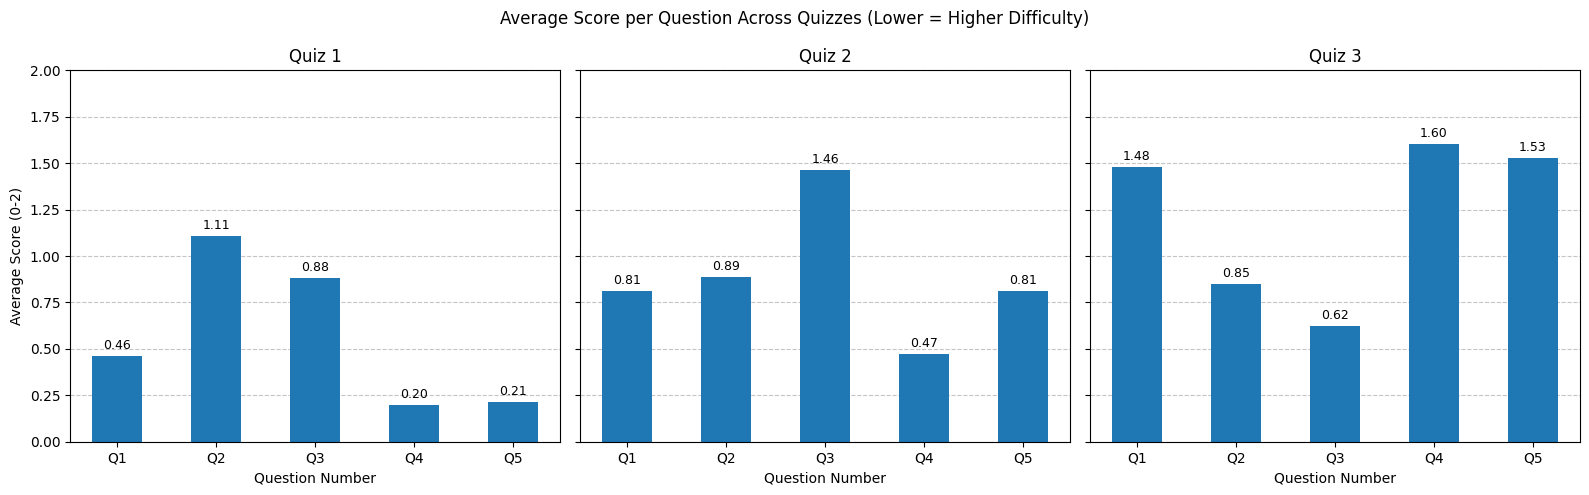

In [14]:
# Average marks visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

x_labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
x = np.arange(len(x_labels))

datasets = [quiz1_data, quiz2_data, quiz3_data]
titles = ["Quiz 1", "Quiz 2", "Quiz 3"]

for i in range(3):
    avg_marks = []

    for column in marks_columns[1:]:
        y = datasets[i][column].mean()
        avg_marks.append(y)

    b = axes[i].bar(x_labels, avg_marks, width=0.5)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Question Number")
    axes[i].set_ylim(0, 2)
    axes[i].grid(linestyle="--", alpha=0.75, axis="y")
    axes[i].set_axisbelow(True)
    axes[i].bar_label(b, fmt="%.2f", padding=3, fontsize=9)

axes[0].set_ylabel("Average Score (0-2)")

fig.suptitle("Average Score per Question Across Quizzes (Lower = Higher Difficulty)")

plt.tight_layout()
plt.show()

**NOTE**: Please note that is is assumed that there is no relationship between quizzes and all 3 quizzes are separate without no significant dependency on the other quizzes.

Accordign to the above chart, it is evident that some questions are hard overall. When comparing all 3 quizzes, Quiz 1 is the most difficult one because the average marks of each question is almost below the 50% of the total marks of each question.

A summary of hardest questions are as follows. (Average score is converted into percentage and depicted inside brackets)
- **Quiz 1**: hardest questions are Q4 (10%) and Q5 (10.5%), followed by Q1 (23.03%).
- **Quiz 2**: Q4 is clearly the hardest (23.5%).
- **Quiz 3**: Q3 is the hardest (31.0%).

In most of the above hardest questions, there is a significant gap between other scores and their scores. Thus, it is evident that there are some questions that are consistently harder than others specially the questions 4 and 5 in Quiz 1, question 4 in Quiz 2, and question 3 in Quiz 3. 

Therefore, the hypothesis can be **partially accepted**. There is an unclear intepretation of the hypothesis related to the relationship between quizzes.
- If the hypothesis means *"within a given quiz, some questions are harder than others"*, it is accepted. The visualizations show that within each quiz, certain questions have significantly lower average marks compared to others.
- If the hypothesis means *"the same question numbers are hardest across all quizzes"*, it is rejected. Since the hardest question numbers differ across quizzes and there is no consistent pattern between them, it cannot be concluded that specific question numbers are universally harder.

Therefore, while question difficulty varies within individual quizzes, it is not consistent across all quizzes. So the most accurate conclusion is that the hypothesis is partially accepted in a cross-quiz sense.

### 4.2 Failure vs Full-Mark Rate
A grouped bar chart is used to visualize the marks distribution across students. This grouped bar chart shows,
- Percentage of students scoring **0 marks** (failure rate)
- Percentage of students scoring **full marks (2)** (full-mark rate)

Please note that, based on the data inspection, it is clear that only possible marks for each question is either *0* or *2*.

This visualization helps to identify, the questions with more failures (harder) and the questions with more perfect scores (easier).

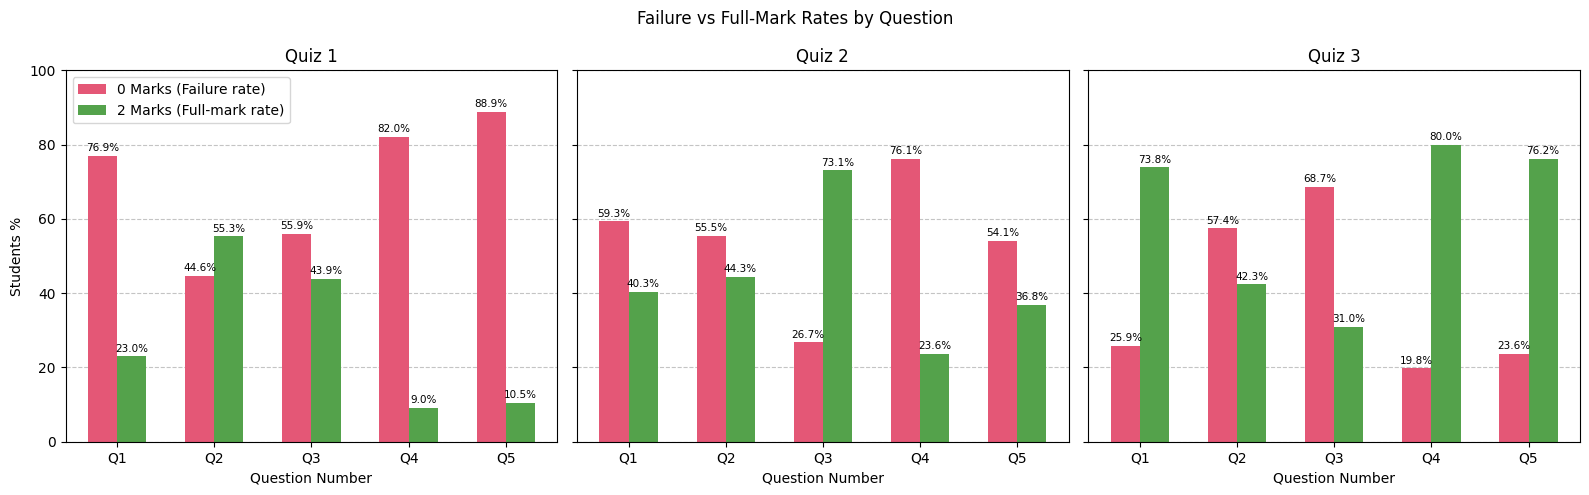

In [15]:
# Value count visualization of all 3 quizzes (marks 0 and 2)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

datasets = [quiz1_data, quiz2_data, quiz3_data]
titles = ["Quiz 1", "Quiz 2", "Quiz 3"]

x_labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
x = np.arange(len(x_labels))
bar_width = 0.30

for i in range(3):
    data = datasets[i]

    # Value counts
    val_counts = {}
    for column in marks_columns[1:]:
        val_counts[column] = data[column].value_counts().sort_index().to_dict()

    # Extract counts for 0 and 2
    marks_0_counts = [val_counts[col].get(0, 0) for col in marks_columns[1:]]
    marks_2_counts = [val_counts[col].get(2, 0) for col in marks_columns[1:]]

    marks_0_percentage = [count/len(data) * 100 for count in marks_0_counts]
    marks_2_percentage = [count/len(data) * 100 for count in marks_2_counts]

    # Plot grouped bar charts
    a0 = axes[i].bar(
        x - bar_width/2, 
        marks_0_percentage, 
        width=bar_width, 
        color="#E45776",
        label='0 Marks (Failure rate)'
    )
    a1 = axes[i].bar(
        x + bar_width/2, 
        marks_2_percentage, 
        width=bar_width, 
        color="#54A24B",
        label='2 Marks (Full-mark rate)'
    )

    axes[i].set_title(titles[i])
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(x_labels)
    axes[i].set_xlabel("Question Number")
    axes[i].grid(axis='y', linestyle='--', alpha=0.75)
    axes[i].set_axisbelow(True)
    axes[i].set_ylim(0, 100)
    axes[i].bar_label(a0, fmt="%.1f%%", padding=2, fontsize=7.5)
    axes[i].bar_label(a1, fmt="%.1f%%", padding=2, fontsize=7.5)

axes[0].set_ylabel("Students %")
axes[0].legend()

fig.suptitle("Failure vs Full-Mark Rates by Question")

plt.tight_layout()
plt.show()

According to the above results, it is evident that some questions are harder to solve for most of the students at their first try further confirming the results of previous visualization. 
- **Quiz 1**: Q4 and Q5 have very high failure rates (82.0% and 88.9%) following Q1 (76.9%).
- **Quiz 2**: Q4 has the highest failure rate (76.1%).
- **Quiz 3**: Q3 has the highest failure rate (68.7%).

In the quiz 1, Q1, Q4, and Q5 has a significant gap between the students who got correct answers and the students who could not solve the questions correctly. Q4 in Quiz 2 and Q3 in Quiz 3 also indicates this quality. All these indicates that some questions are consistently harder than the others.

## Final Decision on the Hypothesis
Using both visualizations, the hypothesis is **accepted within each quiz** (difficulty varies strongly by question), but **not fully supported across quizzes** because the hardest question is not the same in all quizzes.

Therefore, the most defensible conclusion is: **partially accepted**.

<div style="text-align: center;"> *  *  * </div>